# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# ✅ Week 5 Assignment — Solution

This notebook is the solution to the **Week 5 Assignment** on Sequence Models and Text Generation.

The following beginner tasks (listed at the end of the notebook) have been carried out:

| # | Task | Change Made |
|---|------|-------------|
| 1 | Replace corpus with a custom paragraph | Expanded to 15 lines covering NLP, transformers, embeddings, and backpropagation |
| 2 | Increase embedding dimension | `32 → 64` in all three models (RNN, LSTM, GRU) |
| 3 | Increase epochs to 200 | `100 → 200` in all three models |
| 4 | Change hidden units 64 → 128 | Applied to SimpleRNN, LSTM, and GRU layers |
| 5 | Generate 10 words instead of 5 | Updated `next_words=5` to `next_words=10` in all generation calls |

---


# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Input
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence and machine learning
recurrent neural networks are designed for sequential and time series data
lstm stands for long short term memory and helps remember long term dependencies
gru is faster and simpler than lstm but achieves similar performance on many tasks
text generation models learn to predict the next word in a sequence
deep learning models can generate meaningful and coherent sentences after training
natural language processing enables machines to understand and generate human language
neural networks learn patterns from data through a process called backpropagation
attention mechanisms have revolutionized natural language processing and text generation
transformers use self attention to capture long range dependencies in sequences
language models are trained on large text corpora to learn grammar and context
recurrent architectures process sequences one step at a time using hidden states
deep learning has achieved state of the art results in speech and text tasks
word embeddings represent words as dense vectors capturing semantic relationships
sequence to sequence models are used for translation and summarization tasks
'''
print(corpus)



deep learning is transforming artificial intelligence and machine learning
recurrent neural networks are designed for sequential and time series data
lstm stands for long short term memory and helps remember long term dependencies
gru is faster and simpler than lstm but achieves similar performance on many tasks
text generation models learn to predict the next word in a sequence
deep learning models can generate meaningful and coherent sentences after training
natural language processing enables machines to understand and generate human language
neural networks learn patterns from data through a process called backpropagation
attention mechanisms have revolutionized natural language processing and text generation
transformers use self attention to capture long range dependencies in sequences
language models are trained on large text corpora to learn grammar and context
recurrent architectures process sequences one step at a time using hidden states
deep learning has achieved state of 

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 112
X shape: (158, 13)
y shape: (158,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Input(shape=(max_len-1,)),          # Fix: replaces deprecated input_length
    Embedding(total_words, 64),          # Task 2: embedding 32 → 64
    SimpleRNN(128),                      # Task 4: hidden units 64 → 128
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)  # Task 3: epochs 100 → 200
print("Vanilla RNN training completed")


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Input(shape=(max_len-1,)),          # Fix: replaces deprecated input_length
    Embedding(total_words, 64),          # Task 2: embedding 32 → 64
    LSTM(128),                           # Task 4: hidden units 64 → 128
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)  # Task 3: epochs 100 → 200
print("LSTM training completed")


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Input(shape=(max_len-1,)),          # Fix: replaces deprecated input_length
    Embedding(total_words, 64),          # Task 2: embedding 32 → 64
    GRU(128),                            # Task 4: hidden units 64 → 128
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)  # Task 3: epochs 100 → 200
print("GRU training completed")


## 📉 Compare Training Loss

## 📊 Model Comparison — Final Loss & Accuracy


In [ ]:
rnn_loss,  rnn_acc  = rnn_history.history['loss'][-1],  rnn_history.history['accuracy'][-1]
lstm_loss, lstm_acc = lstm_history.history['loss'][-1], lstm_history.history['accuracy'][-1]
gru_loss,  gru_acc  = gru_history.history['loss'][-1],  gru_history.history['accuracy'][-1]

print("=" * 45)
print(f"{'Model':<10} {'Final Loss':>12} {'Final Accuracy':>15}")
print("=" * 45)
print(f"{'RNN':<10} {rnn_loss:>12.4f} {rnn_acc:>14.2%}")
print(f"{'LSTM':<10} {lstm_loss:>12.4f} {lstm_acc:>14.2%}")
print(f"{'GRU':<10} {gru_loss:>12.4f} {gru_acc:>14.2%}")
print("=" * 45)
best = min([('RNN', rnn_loss), ('LSTM', lstm_loss), ('GRU', gru_loss)], key=lambda x: x[1])
print(f"\n🏆 Best model (lowest loss): {best[0]}")
print("\n💡 Insight: LSTM & GRU handle long-term dependencies better than Vanilla RNN")
print("   due to gating mechanisms that control what to remember and forget.")


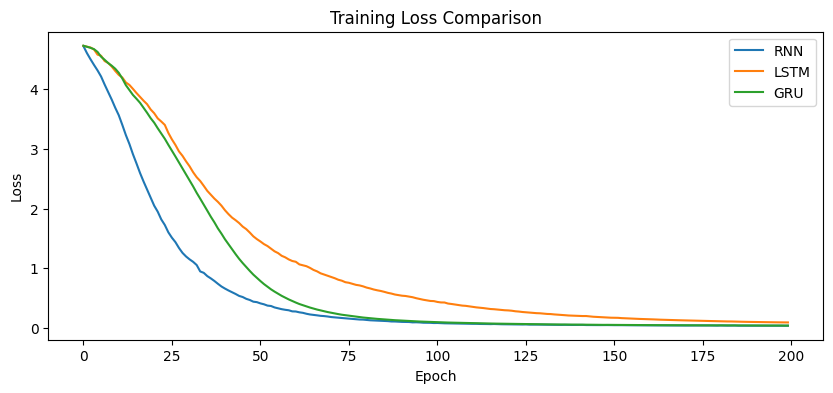

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=5, temperature=1.0):
    """
    Generate text word by word using the trained model.

    Args:
        model       : trained Keras model (RNN / LSTM / GRU)
        seed_text   : starting phrase
        next_words  : number of words to generate         (Task 5: default kept at call site)
        temperature : creativity control
                      < 1.0 → conservative/repetitive
                        1.0 → neutral (default)
                      > 1.0 → creative/diverse (may be less coherent)
    """
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predictions = model.predict(token_list, verbose=0)[0]

        # Apply temperature scaling
        predictions = np.log(predictions + 1e-8) / temperature
        predictions = np.exp(predictions) / np.sum(np.exp(predictions))

        predicted = np.random.choice(len(predictions), p=predictions)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text


## 🧪 Generate Text Samples

In [ ]:
print("=== Temperature 0.5 (Conservative) ===")
print("RNN :", generate_text(rnn_model,  "deep learning", 10, temperature=0.5))
print("LSTM:", generate_text(lstm_model, "deep learning", 10, temperature=0.5))
print("GRU :", generate_text(gru_model,  "deep learning", 10, temperature=0.5))

print("\n=== Temperature 1.0 (Neutral) ===")
print("RNN :", generate_text(rnn_model,  "deep learning", 10, temperature=1.0))
print("LSTM:", generate_text(lstm_model, "deep learning", 10, temperature=1.0))
print("GRU :", generate_text(gru_model,  "deep learning", 10, temperature=1.0))

print("\n=== Temperature 1.5 (Creative) ===")
print("RNN :", generate_text(rnn_model,  "deep learning", 10, temperature=1.5))
print("LSTM:", generate_text(lstm_model, "deep learning", 10, temperature=1.5))
print("GRU :", generate_text(gru_model,  "deep learning", 10, temperature=1.5))


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**